<a href="https://colab.research.google.com/github/Kawaritai/papermage/blob/main/examples/COLAB_concise_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kawaritai/papermage/blob/main/examples/COLAB_concise_demo.ipynb)

# papermage
### "Entity"
Each `Entity` object stores information about its contents and position:

- `.spans: List[Span]` - A `Span` is a pointer into `Document.symbols` (that is, `Span(start=0, end=5)` corresponds to `symbols[0:5]`). By default, when you iterate over an `Entity`, you iterate over its `.spans`.

- `.boxes: List[Box]` - A `Box` represents a rectangular region on the page. Each span is associated a `Box`.

- `.metadata: Metadata` - A free form dictionary-like object to store extra metadata about that `Entity`. These are usually empty.
### "Document"
A `Document` is created by stitching together 3 types of tools: **Parsers**, **Rasterizers** and **Predictors**.

- **Parsers** take a PDF as input and return a `Document` composed of `.symbols` and other layers. The example one we use is a wrapper around PDFPlumber - MIT License utility.

- **Rasterizers** take a PDF as input and return an `Image` per page that is added to `Document.images`. The example one we use is PDF2Image - MIT License.

- **Predictors** take a `Document` and apply some operation to compute a new set of `Entity` objects that we can insert into our `Document`. These are all built in-house and can be either simple heuristics or full machine-learning models.

In [1]:
# FOR COLAB. IF YOU'RE NOT IN COLAB, GO AWAY

# (1/3): Clone papermage
!git clone https://github.com/Kawaritai/papermage.git
%cd papermage

Cloning into 'papermage'...
remote: Enumerating objects: 1879, done.
remote: Counting objects: 100% (683/683), done.
remote: Compressing objects: 100% (313/313), done.
remote: Total 1879 (delta 395), reused 511 (delta 359), pack-reused 1196 (from 1)
Receiving objects: 100% (1879/1879), 50.01 MiB | 26.84 MiB/s, done.
Resolving deltas: 100% (1213/1213), done.
/content/papermage


In [2]:
# (2/3): Run this cell, then "restart session" if prompted so
!pip install -r "/content/papermage/requirements.txt"

Obtaining file:///content/papermage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.1/483.1 kB 16.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.2/112.2 kB 7.6 

In [1]:
# (3/3): Run this cell, then "restart session" if prompted so
!pip install torchdata==0.7.1 torchtune==0.4.0
!apt-get install poppler-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.9/686.9 kB 21.1 MB/s eta 0:00:00
  Attempting uninstall: torchdata
    Found existing installation: torchdata 0.11.0
    Uninstalling torchdata-0.11.0:
      Successfully uninstalled torchdata-0.11.0
  Attempting uninstall: torchtune
    Found existing installation: torchtune 0.6.1
    Uninstalling torchtune-0.6.1:
      Successfully uninstalled torchtune-0.6.1
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.11 [186 kB]
Fetched 186 kB in 0s (1,826 kB/s)
Selecting previously unselected packag

In [2]:
import papermage.recipes as recipes

# May ask for HF_TOKEN access. Just click "Cancel", it's not required.
DOCUMENT_PATH = "/content/papermage/tests/fixtures/papermage.pdf" # from the tests directory
# DOCUMENT_PATH = "/path/to/your.pdf"

# Run recipe on our document
doc = recipes.CoreRecipe().run(DOCUMENT_PATH)

/content/papermage/papermage/predictors/word_predictors.py:192: SyntaxWarning: invalid escape sequence '\w'
  sparse_features["shape"] = re.sub("\w", "x", word)
publaynet-tf_efficientdet_d0.pth.tar?dl=1: 47.1MB [00:03, 13.6MB/s]                            


Downloading: "https://github.com/rwightman/efficientdet-pytorch/releases/download/v0.1/tf_efficientdet_d0_34-f153e0cf.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientdet_d0_34-f153e0cf.pth


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/451M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/451M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

(LPPredictor): 100%|██████████| 13/13 [00:07<00:00,  1.72it/s]


In [3]:
from papermage.magelib import Document

# Go to `papermage.magelib.Document` for documentation
assert type(doc) == Document

print("SPECIAL_FIELDS:",doc.SPECIAL_FIELDS)

display(doc) # shows the same list as doc._layers

SPECIAL_FIELDS: ['symbols', 'images', 'metadata']


Document with 27 layers: ['symbols', 'images', 'metadata', 'tokens', 'rows', 'pages', 'sentences', 'blocks', 'figures', 'tables', 'vila_entities', 'titles', 'paragraphs', 'authors', 'abstracts', 'keywords', 'sections', 'lists', 'bibliographies', 'equations', 'algorithms', 'captions', 'headers', 'footers', 'footnotes', 'Figure', 'Table']

In [4]:
# Document Title
print(f"len(doc.titles): {len(doc.titles)}")

title = doc.titles[0]

print(f"title.spans:", title.spans)
print(f"title.boxes:", title.boxes)
print(f"title.text:", title.text)

len(doc.titles): 1
title.spans: [Span[0, 110]]
title.boxes: [Box[0.16887964574415903, 0.08243732055256615, 0.6622461342301721, 0.03597405836867064, 0]]
title.text: PaperMage: A Unified Toolkit for Processing, Representing, and Manipulating Visually-Rich Scientific Documents


In [5]:
# You can only query Layers using `intersect_by_span` or `intersect_by_box`
print(f"Number of layer kinds: {len(doc.layers)}")
for layer in doc.layers:
    print(f"{layer:15}: {type(doc.__getattribute__(layer))}")

Number of layer kinds: 27
symbols        : <class 'str'>
images         : <class 'list'>
metadata       : <class 'papermage.magelib.metadata.Metadata'>
tokens         : <class 'papermage.magelib.layer.Layer'>
rows           : <class 'papermage.magelib.layer.Layer'>
pages          : <class 'papermage.magelib.layer.Layer'>
sentences      : <class 'papermage.magelib.layer.Layer'>
blocks         : <class 'papermage.magelib.layer.Layer'>
figures        : <class 'papermage.magelib.layer.Layer'>
tables         : <class 'papermage.magelib.layer.Layer'>
vila_entities  : <class 'papermage.magelib.layer.Layer'>
titles         : <class 'papermage.magelib.layer.Layer'>
paragraphs     : <class 'papermage.magelib.layer.Layer'>
authors        : <class 'papermage.magelib.layer.Layer'>
abstracts      : <class 'papermage.magelib.layer.Layer'>
keywords       : <class 'papermage.magelib.layer.Layer'>
sections       : <class 'papermage.magelib.layer.Layer'>
lists          : <class 'papermage.magelib.layer.L

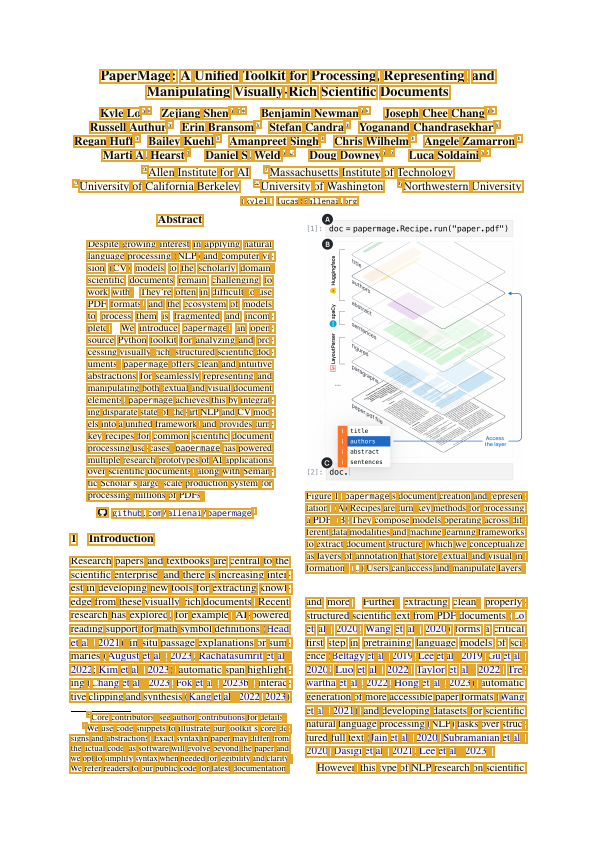

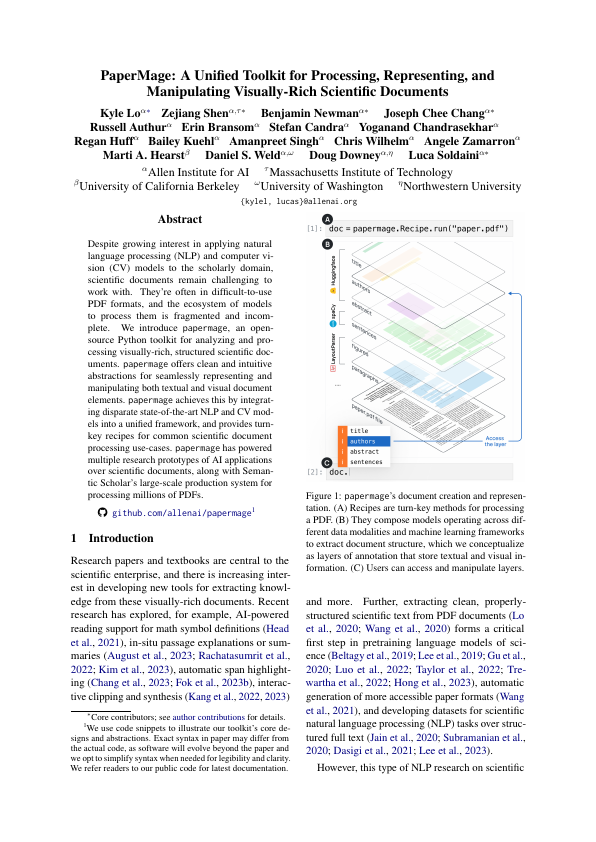

In [7]:
from papermage.visualizers import plot_entities_on_page
import ipywidgets as widgets
from IPython.display import display, clear_output
import colorsys
%matplotlib inline
def showcase_annotations():
    # Helper to generate a colourmap of n colours
    def get_colors(n):
        return ['#%02x%02x%02x' % tuple(int(c*255) for c in colorsys.hsv_to_rgb(i/n, 0.8, 0.9)) for i in range(n)]

    COLOURS = get_colors(len(doc.layers))

    # Create page slider
    page_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(doc.pages) - 1,
        step=1,
        description='Page:',
        continuous_update=False,
        layout=widgets.Layout(width='400px')
    )

    # Create checkboxes for each layer
    checkboxes = {layer: widgets.Checkbox(value=False, description=layer) for layer in doc.layers}
    output = widgets.Output()

    def update_checkbox_labels():
        """Update checkbox labels with entity counts for the current page."""
        page = doc.pages[page_slider.value]
        for layer in doc.layers:
            count = 0
            try:
                # Try to get counts from both within_span and within_box
                span_values = page.within_span(layer)
                box_values = page.within_box(layer)
                # Use the larger count (they might overlap)
                count = max(len(span_values), len(box_values))
            except (TypeError, AttributeError):
                # If we error, count stays 0
                pass

            checkboxes[layer].description = f"{layer} ({count})"

    def update_plot(change):
        # Update checkbox labels when page changes
        if change is None or change.get('name') == 'value' and change['owner'] == page_slider:
            update_checkbox_labels()

        with output:
            clear_output(wait=True)
            page = doc.pages[page_slider.value]
            highlighted = page.images[0]
            for i, layer in enumerate(doc.layers):
                if checkboxes[layer].value:  # Only plot if checked
                    try:
                        # within_span
                        values = page.within_span(layer)
                        highlighted = plot_entities_on_page(highlighted, values, box_color=COLOURS[i], box_alpha=0.05)

                        # within_box
                        values = page.within_box(layer)
                        highlighted = plot_entities_on_page(highlighted, values, box_color=COLOURS[i], box_alpha=0.05)
                    except TypeError:
                        pass
            display(highlighted)

    # Attach update function to slider and checkboxes
    page_slider.observe(update_plot, names='value')
    for cb in checkboxes.values():
        cb.observe(update_plot, names='value')

    # Layout: slider on top, controls on left, image on right
    controls = widgets.VBox(list(checkboxes.values()))
    bottom_layout = widgets.HBox([controls, output])
    full_layout = widgets.VBox([page_slider, bottom_layout])

    display(full_layout)
    update_plot(None)  # Initial render

showcase_annotations() # ok this is a little broken but it's FINE ☺